In [1]:
import pandas as pd
from astroquery.utils.tap.core import TapPlus

In [2]:
# 1. Load your local CSV
df = pd.read_csv("lenses.csv")

# 2. Connect to the Gaia TAP service
gaia = TapPlus(url="https://gea.esac.esa.int/tap-server/tap")

In [6]:
# 3. Construct a batch query string using the RA/Dec rows from your file
# (For very long lists, splitting into blocks of ~50-100 targets is recommended)
conditions = []
for idx, row in df.iterrows():
    conditions.append(
        f"1 = CONTAINS(POINT('ICRS', ra_obs, dec_obs), CIRCLE('ICRS', {row['ra']}, {row['dec']}, 3.0/3600.0))"
    )
query = f"""
SELECT 
    source_id, component_id, observation_id, epoch_obs, ra_obs, dec_obs, g_mag_obs
FROM 
    gaiafpr.lens_observation
WHERE 
    {" OR ".join(conditions)}
ORDER BY 
    source_id, component_id, epoch_obs
"""

In [7]:
# 4. Launch asynchronous job
print("Launching TAP job...")
job = gaia.launch_job_async(query)
results = job.get_results()

Launching TAP job...
INFO: Query finished. [astroquery.utils.tap.core]


In [8]:
# 5. Convert to pandas DataFrame for analysis
epoch_df = results.to_pandas()
print(f"Retrieved {len(epoch_df)} epoch measurements.")

Retrieved 31221 epoch measurements.


In [10]:
epoch_df
epoch_df.to_csv("lenses_epoch_data.csv", index=False)
print("Saved epoch measurements to lenses_epoch_data.csv")

Saved epoch measurements to lenses_epoch_data.csv


In [11]:
from astropy.coordinates import SkyCoord
import astropy.units as u
# 1. Create coordinate objects for the lenses and the epoch observations
lens_coords = SkyCoord(ra=df['ra'].values * u.degree, dec=df['dec'].values * u.degree)
obs_coords = SkyCoord(ra=epoch_df['ra_obs'].values * u.degree, dec=epoch_df['dec_obs'].values * u.degree)
# 2. Match each epoch observation to the nearest lens system in df
idx, d2d, _ = obs_coords.match_to_catalog_sky(lens_coords)
# 3. Create the new combined DataFrame
combined_df = epoch_df.copy()
# Add all columns from the lens DataFrame (prefixed with 'lens_') to the matched observations
for col in df.columns:
    combined_df[f'lens_{col}'] = df[col].values[idx]
# Add the separation distance in arcseconds
combined_df['separation_arcsec'] = d2d.to(u.arcsec).value
# 4. Filter to ensure we only keep matches within the 3.0 arcsecond matching radius
max_sep = 3.0 * u.arcsec
combined_df = combined_df[d2d < max_sep].reset_index(drop=True)
print(f"Created combined_df with {len(combined_df)} rows.")
combined_df.head()

Created combined_df with 31221 rows.


,source_id,component_id,observation_id,epoch_obs,ra_obs,dec_obs,g_mag_obs,lens_name,lens_ra,lens_dec,...,lens_n_img,lens_Gmag,lens_RPmag,lens_BPmag,lens_z_lens,lens_z_lens_type,lens_z_source,lens_z_source_type,lens_LEGACY SURVEY,separation_arcsec
0,78702389482720512,1,9,1822.622740,30.997360,16.202646,20.50000,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.18,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.198828
1,78702389482720512,1,5,1846.042057,30.997386,16.202669,20.31250,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.18,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.224533
2,78702389482720512,1,2,2008.636657,30.997414,16.202658,20.40625,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.18,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.141440
3,78702389482720512,1,1,2061.630025,30.997423,16.202649,20.50000,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.18,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.100838
4,78702389482720512,1,3,2061.806198,30.997416,16.202650,20.62500,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.18,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.114554


In [12]:
combined_df

,source_id,component_id,observation_id,epoch_obs,ra_obs,dec_obs,g_mag_obs,lens_name,lens_ra,lens_dec,...,lens_n_img,lens_Gmag,lens_RPmag,lens_BPmag,lens_z_lens,lens_z_lens_type,lens_z_source,lens_z_source_type,lens_LEGACY SURVEY,separation_arcsec
0,78702389482720512,1,9,1822.622740,30.997360,16.202646,20.500000,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.180,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.198828
1,78702389482720512,1,5,1846.042057,30.997386,16.202669,20.312500,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.180,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.224533
2,78702389482720512,1,2,2008.636657,30.997414,16.202658,20.406250,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.180,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.141440
3,78702389482720512,1,1,2061.630025,30.997423,16.202649,20.500000,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.180,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.100838
4,78702389482720512,1,3,2061.806198,30.997416,16.202650,20.625000,J0203+1612,30.9977,16.20213,...,2.0,20.759,19.461,20.892,0.488,SPECTRO,2.180,SPECTRO,https://www.legacysurvey.org/viewer?ra=30.9977...,2.114554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31216,6896655868835640192,3,25,2364.132551,315.870855,-8.847155,20.265625,J2103-0850,315.8708,-8.84694,...,3.0,18.384,17.413,18.238,NaN,NaN,2.455,SPECTRO,https://www.legacysurvey.org/viewer?ra=315.870...,0.797950
31217,6896655868835640192,3,2,2460.958730,315.870865,-8.847145,20.593750,J2103-0850,315.8708,-8.84694,...,3.0,18.384,17.413,18.238,NaN,NaN,2.455,SPECTRO,https://www.legacysurvey.org/viewer?ra=315.870...,0.772120
31218,6896655868835640192,3,21,2475.036385,315.870848,-8.847158,20.531250,J2103-0850,315.8708,-8.84694,...,3.0,18.384,17.413,18.238,NaN,NaN,2.455,SPECTRO,https://www.legacysurvey.org/viewer?ra=315.870...,0.802526
31219,6896655868835640192,3,31,2641.266509,315.870832,-8.847164,20.250000,J2103-0850,315.8708,-8.84694,...,3.0,18.384,17.413,18.238,NaN,NaN,2.455,SPECTRO,https://www.legacysurvey.org/viewer?ra=315.870...,0.814089


Re-aligning component IDs using spatial clustering...


/tmp/ipykernel_22418/1288560845.py:32: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  centroids, labels = kmeans2(points, k, minit='points', iter=30)
/tmp/ipykernel_22418/1288560845.py:32: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  centroids, labels = kmeans2(points, k, minit='points', iter=30)


Saved cleaned data to 'lenses_epoch_data_cleaned.csv'

Generating and saving clean plots to the 'plots_cleaned/' folder...

Displaying clean sample plot 1/3: J0203+1612


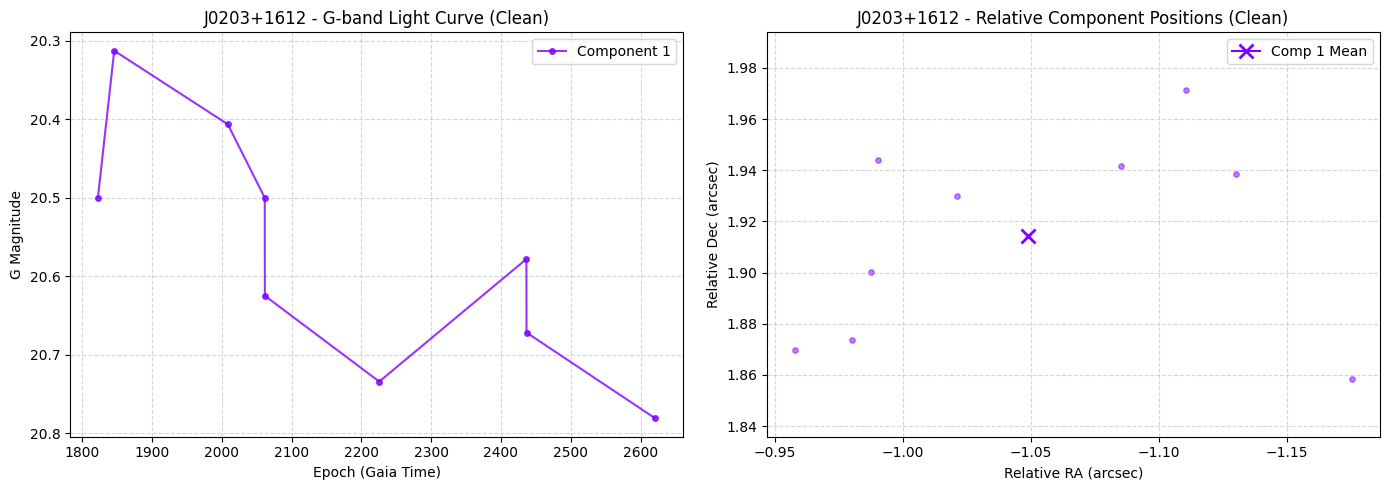


Displaying clean sample plot 2/3: J0248+1913


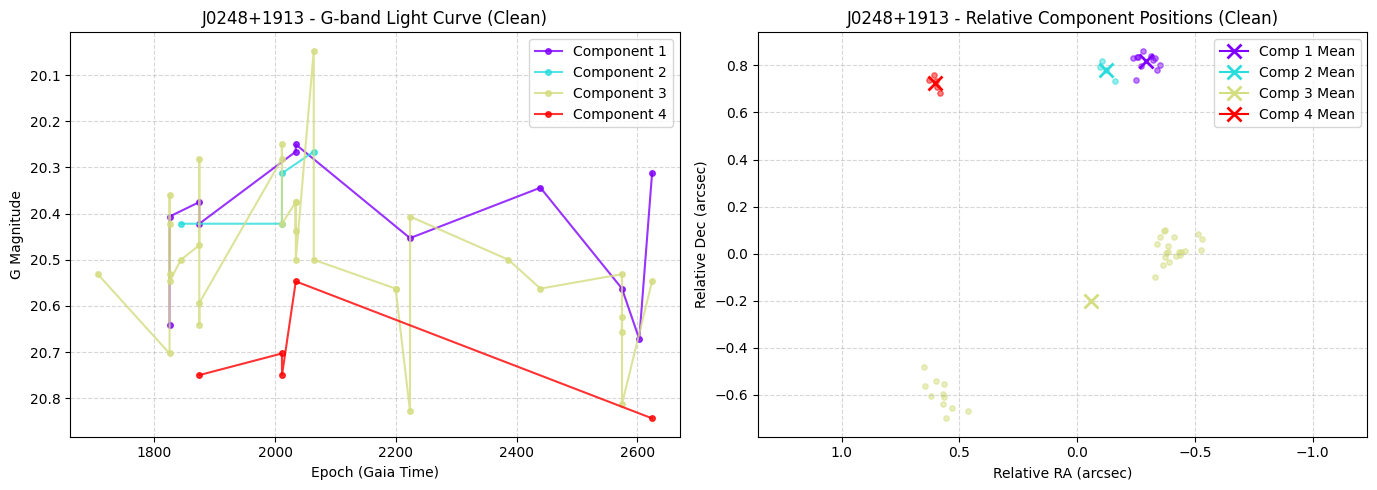


Displaying clean sample plot 3/3: J0417+3325


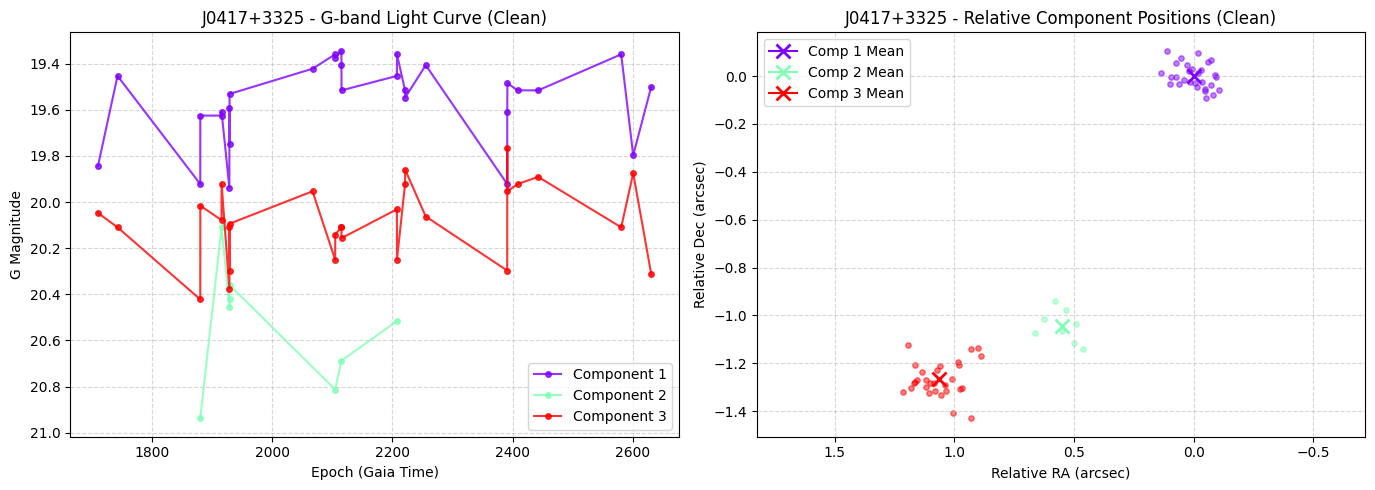


All clean plots have been saved successfully to the 'plots_cleaned/' directory.


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2

def clean_component_ids(df_system):
    """
    Re-assigns component IDs consistently using spatial clustering (K-Means).
    Sorts components by RA so that Component 1 is always the easternmost.
    """
    df_clean = df_system.copy()
    
    # Calculate relative offsets in arcseconds for clustering
    lens_dec_rad = np.radians(df_clean['lens_dec'].iloc[0])
    delta_ra = (df_clean['ra_obs'] - df_clean['lens_ra']) * 3600.0 * np.cos(lens_dec_rad)
    delta_dec = (df_clean['dec_obs'] - df_clean['lens_dec']) * 3600.0
    
    # Combine into a 2D array of positions
    points = np.column_stack((delta_ra, delta_dec))
    
    # Determine number of components based on unique pipeline IDs
    k = len(df_clean['component_id'].unique())
    
    if k <= 1:
        # No swapping is possible with only one component
        df_clean['consistent_component_id'] = 1
        return df_clean
        
    try:
        # Run K-Means clustering to find the true spatial centers
        # minit='points' uses actual data points for robust initialization
        centroids, labels = kmeans2(points, k, minit='points', iter=30)
        
        # Sort centroids by RA (first column) so component IDs are assigned consistently
        # East is left, so sorting by RA offset organizes them spatially
        sort_idx = np.argsort(centroids[:, 0])
        
        # Create a mapping from K-Means cluster labels to sorted component IDs (1-indexed)
        label_map = {old_label: new_label + 1 for new_label, old_label in enumerate(sort_idx)}
        
        # Assign the new consistent component IDs
        df_clean['consistent_component_id'] = [label_map[l] for l in labels]
        
    except Exception as e:
        # Fallback to original component IDs if clustering fails
        print(f"Clustering failed for a system: {e}. Falling back to original IDs.")
        df_clean['consistent_component_id'] = df_clean['component_id']
        
    return df_clean

def plot_lens_system(system_name, df_system, save_dir=None):
    """
    Plots the G-band light curve (left) and relative spatial positions (right) 
    using consistent component IDs.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Get unique consistent components in this system
    components = sorted(df_system['consistent_component_id'].unique())
    
    # Color palette for components
    colors = plt.cm.rainbow(np.linspace(0, 1, len(components)))
    
    for comp_id, color in zip(components, colors):
        comp_data = df_system[df_system['consistent_component_id'] == comp_id].sort_values('epoch_obs')
        if len(comp_data) == 0:
            continue
            
        # 1. Plot G-band Light Curve (Flux/Mag vs. Epoch)
        ax1.plot(comp_data['epoch_obs'], comp_data['g_mag_obs'], 
                 'o-', color=color, label=f'Component {comp_id}', 
                 markersize=4, alpha=0.8)
        
        # 2. Plot Astrometry Curve (Relative Spatial Offsets)
        lens_dec_rad = np.radians(comp_data['lens_dec'].iloc[0])
        delta_ra = (comp_data['ra_obs'] - comp_data['lens_ra']) * 3600.0 * np.cos(lens_dec_rad)
        delta_dec = (comp_data['dec_obs'] - comp_data['lens_dec']) * 3600.0
        
        # Scatter individual epoch measurements
        ax2.scatter(delta_ra, delta_dec, color=color, s=15, alpha=0.5)
        
        # Plot mean position as a reference cross
        ax2.plot(delta_ra.mean(), delta_dec.mean(), marker='x', color=color, 
                 markersize=10, markeredgewidth=2, label=f'Comp {comp_id} Mean')
        
    # Format Light Curve Subplot
    ax1.set_title(f'{system_name} - G-band Light Curve (Clean)')
    ax1.set_xlabel('Epoch (Gaia Time)')
    ax1.set_ylabel('G Magnitude')
    ax1.invert_yaxis()  # Astronomical standard: brighter is up
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()
    
    # Format Astrometry Subplot
    ax2.set_title(f'{system_name} - Relative Component Positions (Clean)')
    ax2.set_xlabel('Relative RA (arcsec)')
    ax2.set_ylabel('Relative Dec (arcsec)')
    ax2.invert_xaxis()  # Astronomical standard: East is left
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()
    ax2.axis('equal')
    
    plt.tight_layout()
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f'{system_name}.png'), dpi=150)
        plt.close()
    else:
        plt.show()

# --- Process Data and Generate Clean Plots ---
print("Re-aligning component IDs using spatial clustering...")

# Apply spatial clustering to each system separately to clean the component IDs
cleaned_systems = []
for lens_name in combined_df['lens_name'].unique():
    system_data = combined_df[combined_df['lens_name'] == lens_name]
    cleaned_systems.append(clean_component_ids(system_data))

# Combine back into a single clean DataFrame
combined_clean_df = pd.concat(cleaned_systems, ignore_index=True)

# Save the cleaned DataFrame to a new CSV file
combined_clean_df.to_csv("lenses_epoch_data_cleaned.csv", index=False)
print("Saved cleaned data to 'lenses_epoch_data_cleaned.csv'")

# Regenerate and save plots
plot_directory = "plots_cleaned"
unique_lenses = combined_clean_df['lens_name'].unique()

print(f"\nGenerating and saving clean plots to the '{plot_directory}/' folder...")
for i, lens_name in enumerate(unique_lenses):
    system_data = combined_clean_df[combined_clean_df['lens_name'] == lens_name]
    
    # Save the clean plots to disk
    plot_lens_system(lens_name, system_data, save_dir=plot_directory)
    
    # Display the first 3 clean plots in the notebook
    if i < 3:
        print(f"\nDisplaying clean sample plot {i+1}/3: {lens_name}")
        plot_lens_system(lens_name, system_data)

print(f"\nAll clean plots have been saved successfully to the '{plot_directory}/' directory.")


In [22]:
import numpy as np
import pandas as pd

# 1. Calculate relative spatial offsets (dra, ddec) in arcseconds for each row
lens_dec_rad = np.radians(combined_clean_df['lens_dec'])
combined_clean_df['dra'] = (combined_clean_df['ra_obs'] - combined_clean_df['lens_ra']) * 3600.0 * np.cos(lens_dec_rad)
combined_clean_df['ddec'] = (combined_clean_df['dec_obs'] - combined_clean_df['lens_dec']) * 3600.0

# 2. Pivot the DataFrame using pivot_table to handle duplicate entries gracefully
pivoted = combined_clean_df.pivot_table(
    index=['lens_name', 'epoch_obs'],
    columns='consistent_component_id',
    values=['g_mag_obs', 'dra', 'ddec', 'ra_obs', 'dec_obs'],
    aggfunc='first'
)

# 3. Flatten the multi-index columns (e.g. ('g_mag_obs', 1) becomes 'g_mag_C1')
pivoted.columns = [f"{val.replace('_obs', '')}_C{comp}" for val, comp in pivoted.columns]

# 4. Reset the index to make 'lens_name' and 'epoch_obs' regular columns
friendly_df = pivoted.reset_index()

# Merge with the original df to include all SLED catalog columns
# Left join on lens_name (friendly_df) and name (df)
friendly_df = pd.merge(friendly_df, df, left_on='lens_name', right_on='name', how='left')
friendly_df = friendly_df.drop(columns=['name'])  # Drop the redundant name column

# 5. Sort logically by lens name and epoch
friendly_df = friendly_df.sort_values(['lens_name', 'epoch_obs']).reset_index(drop=True)

# Save the friendly DataFrame to a new CSV file
friendly_df.to_csv("lenses_time_series_friendly.csv", index=False)
print("Successfully created 'lenses_time_series_friendly.csv' with all original catalog columns.")
friendly_df.head()


Successfully created 'lenses_time_series_friendly.csv' with all original catalog columns.


,lens_name,epoch_obs,ddec_C1,ddec_C2,ddec_C3,ddec_C4,ddec_C5,ddec_C6,dec_C1,dec_C2,...,image_sep,n_img,Gmag,RPmag,BPmag,z_lens,z_lens_type,z_source,z_source_type,LEGACY SURVEY
0,2M1134-2103,1682.456294,-1.439894,NaN,NaN,NaN,NaN,NaN,-21.056650,NaN,...,3.68,4.0,18.937,16.257,16.889,NaN,NaN,2.77,SPECTRO,https://www.legacysurvey.org/viewer?ra=173.668...
1,2M1134-2103,1682.456295,NaN,NaN,-0.703411,NaN,NaN,NaN,NaN,NaN,...,3.68,4.0,18.937,16.257,16.889,NaN,NaN,2.77,SPECTRO,https://www.legacysurvey.org/viewer?ra=173.668...
2,2M1134-2103,1682.456295,NaN,0.68969,NaN,NaN,NaN,NaN,NaN,-21.056058,...,3.68,4.0,18.937,16.257,16.889,NaN,NaN,2.77,SPECTRO,https://www.legacysurvey.org/viewer?ra=173.668...
3,2M1134-2103,1682.456295,NaN,NaN,NaN,1.139918,NaN,NaN,NaN,NaN,...,3.68,4.0,18.937,16.257,16.889,NaN,NaN,2.77,SPECTRO,https://www.legacysurvey.org/viewer?ra=173.668...
4,2M1134-2103,1682.706443,-1.465630,NaN,NaN,NaN,NaN,NaN,-21.056657,NaN,...,3.68,4.0,18.937,16.257,16.889,NaN,NaN,2.77,SPECTRO,https://www.legacysurvey.org/viewer?ra=173.668...


In [18]:
friendly_df['mag_diff_C1_C2'] = friendly_df['g_mag_C1'] - friendly_df['g_mag_C2']


In [19]:
friendly_df['sep_C1_C2_arcsec'] = np.sqrt(
    (friendly_df['dra_C1'] - friendly_df['dra_C2'])**2 + 
    (friendly_df['ddec_C1'] - friendly_df['ddec_C2'])**2
)


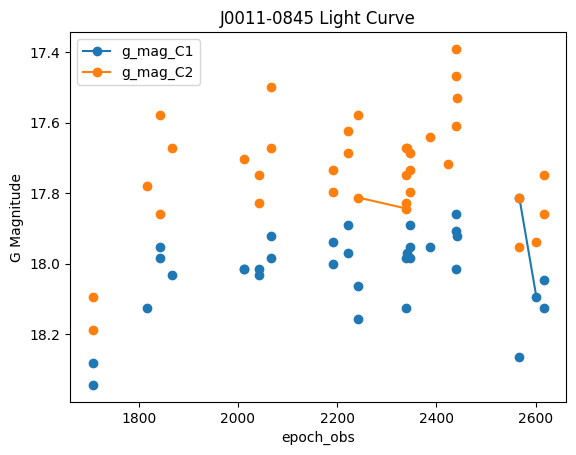

In [21]:
# Filter for one system and plot G magnitude vs Epoch
system_df = friendly_df[friendly_df['lens_name'] == 'H1413+117']
system_df.plot(x='epoch_obs', y=['g_mag_C1', 'g_mag_C2'], marker='o', linestyle='-')
import matplotlib.pyplot as plt
plt.gca().invert_yaxis()  # Brighter is up
plt.title("J0011-0845 Light Curve")
plt.ylabel("G Magnitude")
plt.show()